# Solutions · Coding Exercise 1: Agents and Pipes

Every part solved, run, and explained plainly. Two ways to run a model sit side by side:

- an **agent**: a model in a loop that can call tools, for when the task needs to fetch or act
- a **pipe** (LCEL): a straight line of `prompt | model | parser`, for when there are no tools

This notebook runs with no credentials. The model is a scripted stand-in, the LangChain code is real. One line swaps in Bedrock.

```python
# The only change for the live lab:
from langchain_aws import ChatBedrockConverse
model = ChatBedrockConverse(model="us.anthropic.claude-haiku-4-5-20251001-v1:0", region_name="us-east-1", temperature=0)
```

### Setup

Run this first. It defines the scripted model and imports the pieces every part uses.

In [1]:
from typing import Any, List
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage
from langchain_core.outputs import ChatResult, ChatGeneration
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda


class ScriptedChatModel(BaseChatModel):
    '''Deterministic stand-in so this notebook runs offline.
    The framework code is real. Swap for ChatBedrockConverse on the lab.'''
    responses: List[Any]
    idx: int = 0

    @property
    def _llm_type(self) -> str:
        return "scripted"

    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        reply = self.responses[min(self.idx, len(self.responses) - 1)]
        object.__setattr__(self, "idx", self.idx + 1)
        return ChatResult(generations=[ChatGeneration(message=reply)])

    def bind_tools(self, tools, **kwargs):
        return self


def show(result):
    for m in result["messages"]:
        label = type(m).__name__
        if getattr(m, "tool_calls", None):
            c = m.tool_calls[0]
            print(f"{label:14} -> calls {c['name']}({c['args']})")
        else:
            print(f"{label:14} -> {m.content}")


print("ready")

ready


---
## Part 1 · A tool and an agent

**The picture.** The model cannot read a booking system on its own. Give it a tool, and the loop does the fetching.

```mermaid
flowchart TD
    U[user: is JX48Q2 cancelled?] --> M[model]
    M -->|call lookup_pnr| T[tool reads the record]
    T --> M2[model writes the grounded answer]
    M2 --> A[final answer]
```

**Layman version.** You ask a travel agent a question. They do not know your booking by heart, so they look it up in the system, read the record, then answer you. The tool is the system, the loop is the looking-up.

**The solution:** a docstring the model can act on, a safe return on a missing PNR, the tool wired into `create_agent`, and the final text read off the last message.

In [2]:
BOOKINGS = {"JX48Q2": "BLR-DEL cancelled, Rao, Gold tier"}


@tool
def lookup_pnr(pnr: str) -> str:
    '''Return the booking status for a PNR when the user asks about a booking.'''
    return BOOKINGS.get(pnr, "PNR not found")


model = ScriptedChatModel(responses=[
    AIMessage(content="", tool_calls=[{"name": "lookup_pnr", "args": {"pnr": "JX48Q2"}, "id": "t1", "type": "tool_call"}]),
    AIMessage(content="JX48Q2 on BLR-DEL is cancelled. You are Gold tier, so rebooking is free."),
])

agent = create_agent(model, tools=[lookup_pnr], system_prompt="You are TravelMind.")
result = agent.invoke({"messages": [{"role": "user", "content": "is JX48Q2 cancelled?"}]})
show(result)

HumanMessage   -> is JX48Q2 cancelled?
AIMessage      -> calls lookup_pnr({'pnr': 'JX48Q2'})
ToolMessage    -> BLR-DEL cancelled, Rao, Gold tier
AIMessage      -> JX48Q2 on BLR-DEL is cancelled. You are Gold tier, so rebooking is free.


**What happened, step by step:**

- the human question entered the loop
- the model chose `lookup_pnr` and passed `pnr="JX48Q2"`, which is why it read the docstring
- the tool returned the record, added as a `ToolMessage`
- the model turned that record into the answer

Four messages. Every claim in the reply traces to the tool, not to a guess.

> **Skeptic's corner.** The tool docstring is not a comment. It is the only thing the model reads to decide when to call the tool. A vague docstring is a broken interface, and the model will call the wrong tool at the wrong time.

### A small intuition: counting messages reads the loop

Each tool round trip adds exactly two messages, one for the model asking, one for the tool answering. Count them and you can see how many times the loop turned.

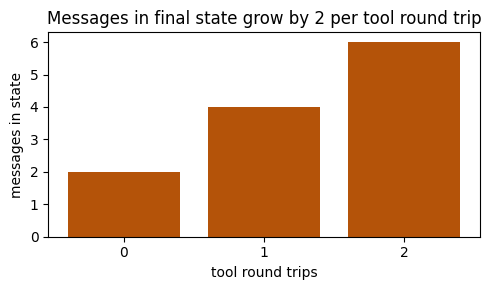

In [3]:
import matplotlib.pyplot as plt

round_trips = [0, 1, 2]
messages_in_state = [2, 4, 6]   # bare = 2, then +2 per tool round trip

plt.figure(figsize=(5, 3))
plt.bar([str(r) for r in round_trips], messages_in_state, color="#B45309")
plt.title("Messages in final state grow by 2 per tool round trip")
plt.xlabel("tool round trips")
plt.ylabel("messages in state")
plt.tight_layout()
plt.show()

---
## Part 2 · The same job as an LCEL pipe

**The picture.** No tools here. The prompt packs the input, the model answers, the parser unwraps a plain string.

```mermaid
flowchart LR
    IN[input dict] --> P[ChatPromptTemplate] --> M[model] --> O[StrOutputParser] --> S[plain string]
```

**Layman version.** An assembly line. The prompt puts your request in a box, the model works on the box, the parser opens it and hands you the plain contents. Three stations, joined by the `|` belt.

**The solution:** a prompt with a system and human line, composed with the model and a string parser, invoked with the template variables.

In [4]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are TravelMind."),
    ("human", "Summarise the disruption for {pnr} in one sentence."),
])

model = ScriptedChatModel(responses=[AIMessage(content="JX48Q2 on BLR-DEL is cancelled; Gold tier rebooks free.")])

chain = prompt | model | StrOutputParser()

out = chain.invoke({"pnr": "JX48Q2"})
print(out)
print("type:", type(out).__name__, "| is a plain string:", isinstance(out, str))

JX48Q2 on BLR-DEL is cancelled; Gold tier rebooks free.
type: TextAccessor | is a plain string: True


**What happened:**

- `invoke({"pnr": "JX48Q2"})` filled the template, producing real messages
- the model answered with an `AIMessage`
- `StrOutputParser` stripped it to a plain string, which is why the output is not wrapped in `content=...`

Drop the parser and you get an `AIMessage` back. Reverse the order and the model receives a template instead of messages, and it breaks.

**Agent or pipe?**

| | Agent | Pipe |
|---|---|---|
| Needs tools | yes | no |
| Runs a loop | yes | no, one pass |
| Reach for it when | you must fetch or act | you just want a clean answer |

Part 1 spun up a whole loop. Part 2 answered with three composed objects. Same model, far less machinery. The pipe is the honest choice when nothing needs fetching.

---
## Part 3 · Debug and fix

The broken agent had three faults. Here they are, named and corrected.

```mermaid
flowchart LR
    B1[from langchain import create_agent] --> F1[from langchain.agents import create_agent]
    B2[tools=lookup_pnr] --> F2[tools=[lookup_pnr]]
    B3[invoke a bare string] --> F3[invoke a messages dict]
```

| Line | Fault | Fix |
|---|---|---|
| L1 | wrong import path | `from langchain.agents import create_agent` |
| L11 | a tool where a list is expected | `tools=[lookup_pnr]` |
| L12 | wrong input shape | `agent.invoke({"messages": [{"role": "user", "content": "..."}]})` |

The corrected, running version:

In [3]:
# from langchain.agents import create_agent   # correct import (already imported in setup)

BOOKINGS = {"JX48Q2": "BLR-DEL cancelled, Rao, Gold tier"}


@tool
def lookup_pnr(pnr: str) -> str:
    '''Return the booking status for a PNR.'''
    return BOOKINGS.get(pnr, "PNR not found")


model = ScriptedChatModel(responses=[
    AIMessage(content="", tool_calls=[{"name": "lookup_pnr", "args": {"pnr": "JX48Q2"}, "id": "t1", "type": "tool_call"}]),
    AIMessage(content="JX48Q2 is cancelled on BLR-DEL."),
])

agent = create_agent(model, tools=[lookup_pnr], system_prompt="You are TravelMind.")   # tools is a list
result = agent.invoke({"messages": [{"role": "user", "content": "is JX48Q2 cancelled?"}]})   # messages dict

print("final text only:", result["messages"][-1].content)

final text only: JX48Q2 is cancelled on BLR-DEL.


**Why each one bit:**

- the wrong import raises `ImportError` before anything runs
- `tools` expects a list, so a bare tool is a type error the framework rejects
- `invoke` expects a messages dict, and a bare string does not carry the role the loop needs

Printing `result` alone dumps the whole state. `result["messages"][-1].content` is the one line a user should see.

---
## Part 4 · Strands to LangChain

The tool definition ports unchanged. Only the model constructor, the agent constructor, and the run-and-read lines differ.

| Strands | LangChain |
|---|---|
| `BedrockModel(model_id=..., region_name=...)` | `ChatBedrockConverse(model=..., region_name=...)` |
| `Agent(model=, system_prompt=, tools=[...])` | `create_agent(model, tools=[...], system_prompt=)` |
| `agent("...")` | `agent.invoke({"messages": [...]})` |
| `str(result)` | `result["messages"][-1].content` |

The LangChain version, running:

In [4]:
@tool
def disruption_reason(flight: str) -> str:
    '''Return why a flight was cancelled or delayed, given its flight number.'''
    return "weather hold at BLR"


# Live lab: model = ChatBedrockConverse(model="us.anthropic.claude-haiku-4-5-20251001-v1:0", region_name="us-east-1")
model = ScriptedChatModel(responses=[
    AIMessage(content="", tool_calls=[{"name": "disruption_reason", "args": {"flight": "AI-506"}, "id": "d1", "type": "tool_call"}]),
    AIMessage(content="AI-506 was delayed by a weather hold at BLR."),
])

agent = create_agent(model, tools=[disruption_reason], system_prompt="You are TravelMind.")
result = agent.invoke({"messages": [{"role": "user", "content": "why was AI-506 delayed?"}]})
print(result["messages"][-1].content)

AI-506 was delayed by a weather hold at BLR.


**The takeaway.** Your tool design carries across frameworks for free. The `@tool` function and its docstring are identical. The differences live in how you build the model, build the agent, run it, and read the result.

---
## Part 5 · Feed a pipe's output into the agent

**The picture.** A pipe builds a clean instruction, then hands it to the agent. An agent can live inside an LCEL chain as just another step.

```mermaid
flowchart LR
    IN[pnr] --> Q[build a question string] --> AG[agent step] --> TXT[final text]
```

**The solution:** two `RunnableLambda` steps, composed with `|`.

In [5]:
BOOKINGS = {"JX48Q2": "BLR-DEL cancelled, Rao, Gold tier"}


@tool
def lookup_pnr(pnr: str) -> str:
    '''Return the booking status for a PNR when the user asks about a booking.'''
    return BOOKINGS.get(pnr, "PNR not found")


model = ScriptedChatModel(responses=[
    AIMessage(content="", tool_calls=[{"name": "lookup_pnr", "args": {"pnr": "JX48Q2"}, "id": "t1", "type": "tool_call"}]),
    AIMessage(content="JX48Q2 on BLR-DEL is cancelled. Gold tier, free rebooking."),
])
agent = create_agent(model, tools=[lookup_pnr], system_prompt="You are TravelMind.")

build_question = RunnableLambda(lambda d: f"Please check booking {d['pnr']} and tell me the status.")
ask_agent = RunnableLambda(lambda q: agent.invoke({"messages": [{"role": "user", "content": q}]})["messages"][-1].content)

chain = build_question | ask_agent
print(chain.invoke({"pnr": "JX48Q2"}))

JX48Q2 on BLR-DEL is cancelled. Gold tier, free rebooking.


**What happened:**

- `build_question` turned `{"pnr": "JX48Q2"}` into a clean instruction string
- `ask_agent` ran the agent on that string and returned only the final text
- the `|` joined them into one chain, invoked once

`RunnableLambda` wraps any function into a pipe step, which is why an agent, a model, and a plain function can all sit in the same chain.

---
## What this exercise practised

- built an agent and an LCEL pipe, and saw when each fits
- read a diagram and turned it into a composed pipe
- fixed the three bugs that stop most first agents: the import, the tools list, the invoke shape
- ported a Strands agent to LangChain with the tool unchanged
- composed a pipe and an agent into one chain

> **Forward look.** Model APIs will keep shifting. The pipe and the loop will not. Anchor on those two shapes and the method names become a lookup table.